In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams.update({'figure.figsize':(12,5), 'axes.grid':True, 'grid.alpha':0.3})

DATA_DIR=''   # '/content/' in Colab
exp  = pd.read_csv(DATA_DIR+'Tea_Export_Master_2008_2024.csv')
glob = pd.read_csv(DATA_DIR+'DateGlobal_Tea_Price.csv')
df = pd.merge(exp,glob,on=['Year','Month'])
df['Date']=pd.to_datetime(df['Year'].astype(str)+'-'+df['Month'],format='%Y-%B')
df=df.set_index('Date').sort_index(); df.index.freq='MS'
df['Export Quantity (kg)']=pd.to_numeric(df['Export Quantity (kg)'],errors='coerce')

price = df['Export Price (LKR/kg)']        # RAW target — no log anywhere
print('Range:', df.index.min().date(),'->',df.index.max().date(),'| n =',len(df))
df.head()

Range: 2008-01-01 -> 2024-12-01 | n = 204


,Year,Month,Export Quantity (kg),Export Price (LKR/kg),Exchange Rate (LKR/USD),Export Price (USD/kg),Global_Tea_Price ($)
Date,,,,,,,
2008-01-01,2008,January,25100000.0,385.12,108.166956,3.560422,2.38
2008-02-01,2008,February,23850000.0,398.40,107.845238,3.694183,2.40
2008-03-01,2008,March,27200000.0,412.55,107.731905,3.829413,2.26
2008-04-01,2008,April,21400000.0,425.30,107.803182,3.945153,2.49
2008-05-01,2008,May,28500000.0,438.10,107.787273,4.064487,2.48


---
# Part 1 — Data Visualisation

Every chart below is a candidate panel for the dashboard. They are grouped: **(A) the price over time**, **(B) distribution & volatility**, **(C) seasonality check**, **(D) drivers & relationships**.

## A. Price over time

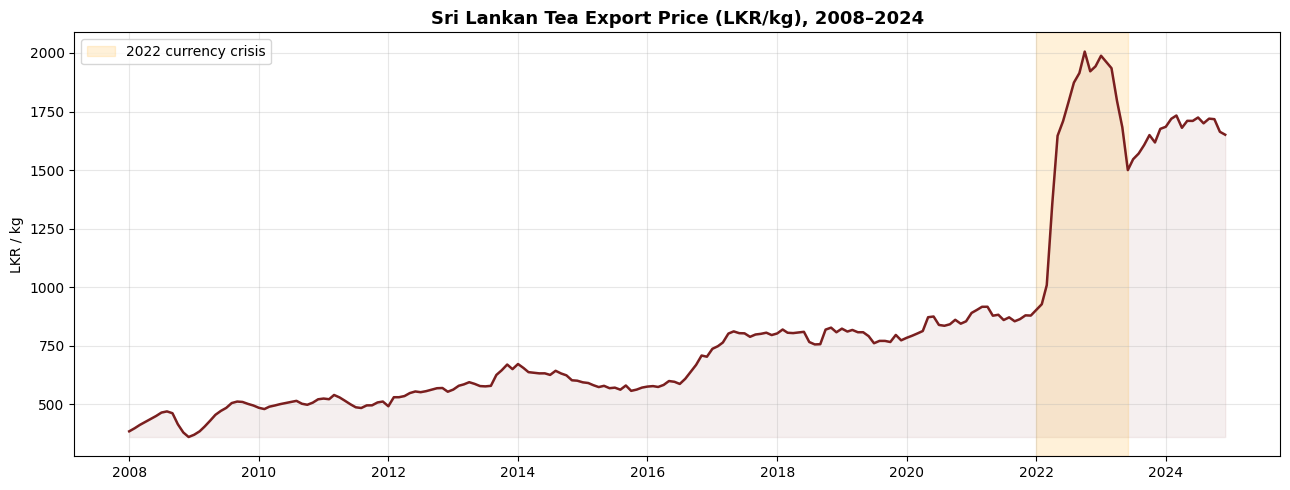

In [ ]:
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(price.index, price, color='#7a1f1f', lw=1.8)
ax.fill_between(price.index, price, price.min(), color='#7a1f1f', alpha=0.07)
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2023-06-01'), color='orange', alpha=0.15, label='2022 currency crisis')
ax.set_title('Sri Lankan Tea Export Price (LKR/kg), 2008–2024', fontsize=13, weight='bold')
ax.set_ylabel('LKR / kg'); ax.legend(); plt.tight_layout(); plt.show()

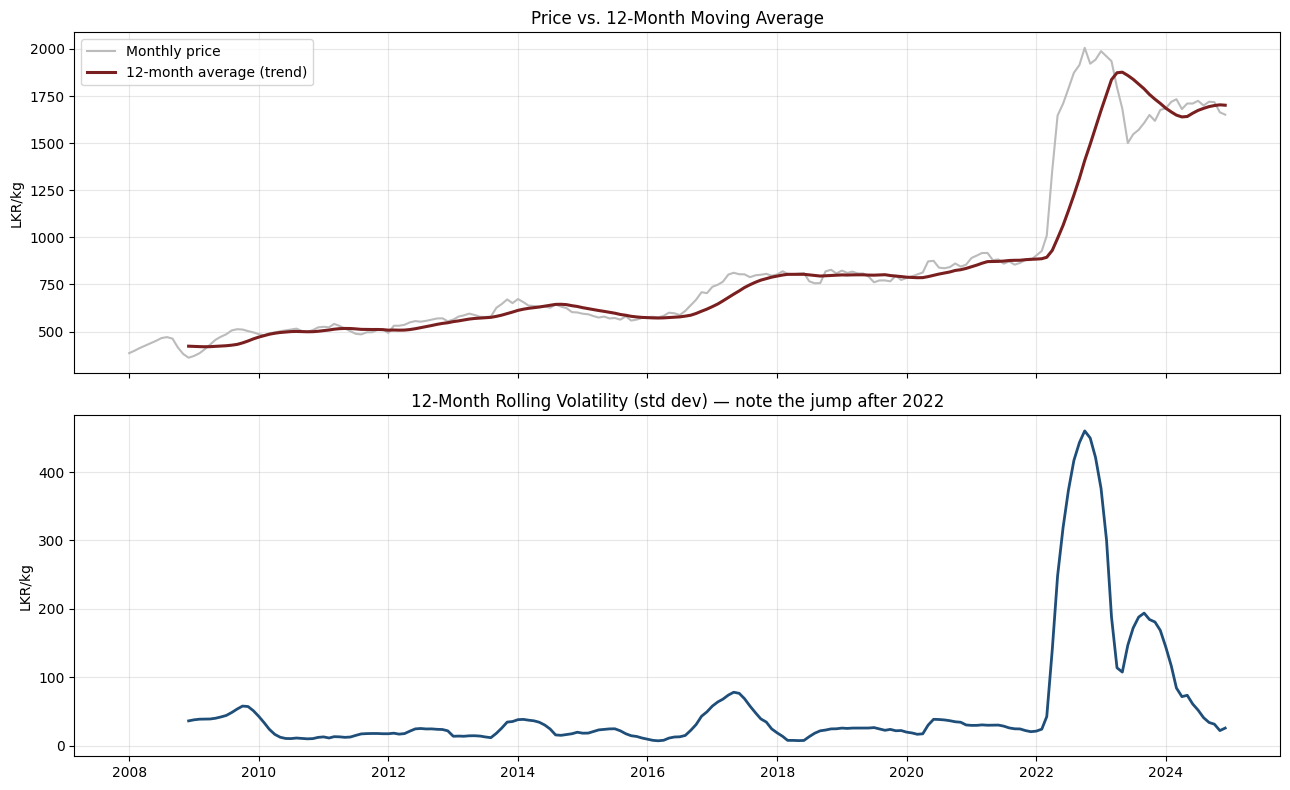

In [ ]:
# Trend & volatility: 12-month rolling mean and rolling std
roll_m = price.rolling(12).mean(); roll_s = price.rolling(12).std()
fig, ax = plt.subplots(2,1,figsize=(13,8),sharex=True)
ax[0].plot(price.index, price, color='#bbb', label='Monthly price')
ax[0].plot(roll_m.index, roll_m, color='#7a1f1f', lw=2.2, label='12-month average (trend)')
ax[0].set_title('Price vs. 12-Month Moving Average'); ax[0].set_ylabel('LKR/kg'); ax[0].legend()
ax[1].plot(roll_s.index, roll_s, color='#1f4e79', lw=2)
ax[1].set_title('12-Month Rolling Volatility (std dev) — note the jump after 2022')
ax[1].set_ylabel('LKR/kg'); plt.tight_layout(); plt.show()

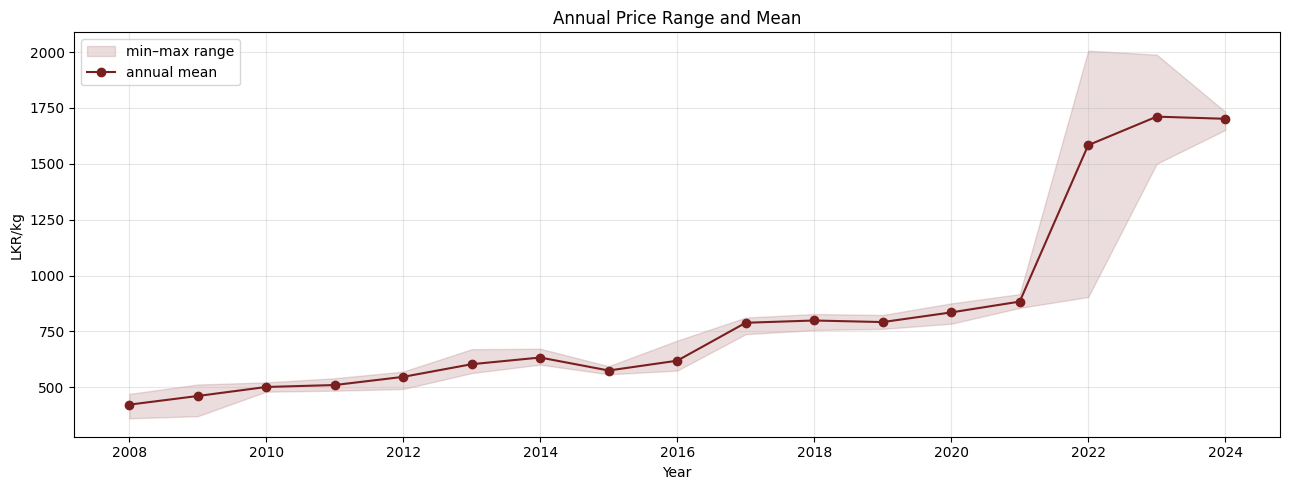

,min,mean,max
Date,,,
2020,784.2,834.8,875.2
2021,854.9,883.3,916.8
2022,903.8,1583.3,2005.9
2023,1500.1,1710.9,1988.2
2024,1651.1,1701.3,1733.2


In [ ]:
# Annual summary: min / mean / max per year
annual = price.groupby(price.index.year).agg(['min','mean','max'])
fig, ax = plt.subplots(figsize=(13,5))
ax.fill_between(annual.index, annual['min'], annual['max'], color='#7a1f1f', alpha=0.15, label='min–max range')
ax.plot(annual.index, annual['mean'], 'o-', color='#7a1f1f', label='annual mean')
ax.set_title('Annual Price Range and Mean'); ax.set_xlabel('Year'); ax.set_ylabel('LKR/kg')
ax.legend(); plt.tight_layout(); plt.show()
annual.round(1).tail()

## B. Distribution & volatility

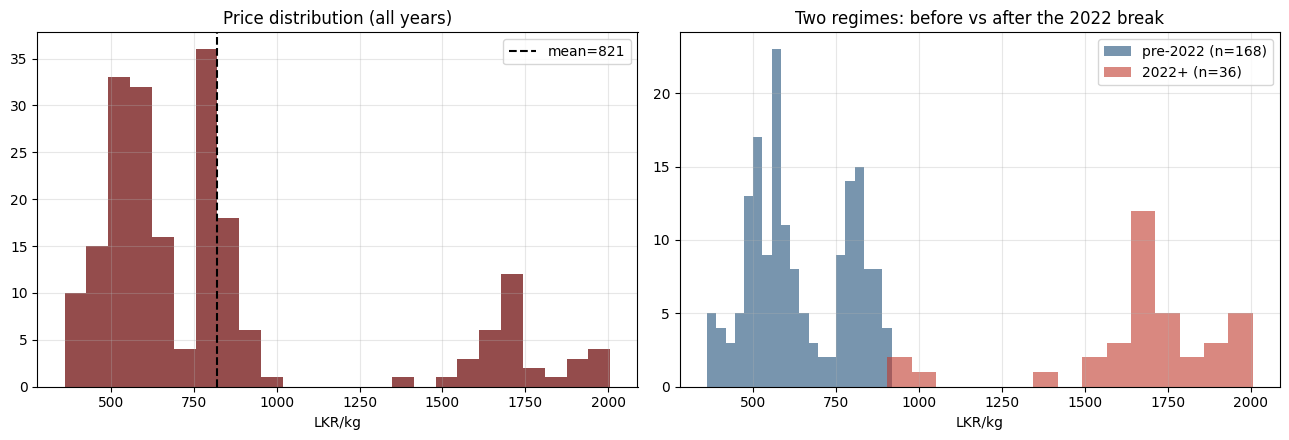

In [ ]:
# Distribution overall and split by regime (pre/post 2022 break)
pre  = price[price.index <  '2022-01-01']
post = price[price.index >= '2022-01-01']
fig, ax = plt.subplots(1,2,figsize=(13,4.5))
ax[0].hist(price, bins=25, color='#7a1f1f', alpha=0.8)
ax[0].axvline(price.mean(), color='k', ls='--', label=f'mean={price.mean():.0f}')
ax[0].set_title('Price distribution (all years)'); ax[0].set_xlabel('LKR/kg'); ax[0].legend()
ax[1].hist(pre, bins=20, color='#1f4e79', alpha=0.6, label=f'pre-2022 (n={len(pre)})')
ax[1].hist(post, bins=15, color='#c0392b', alpha=0.6, label=f'2022+ (n={len(post)})')
ax[1].set_title('Two regimes: before vs after the 2022 break'); ax[1].set_xlabel('LKR/kg'); ax[1].legend()
plt.tight_layout(); plt.show()

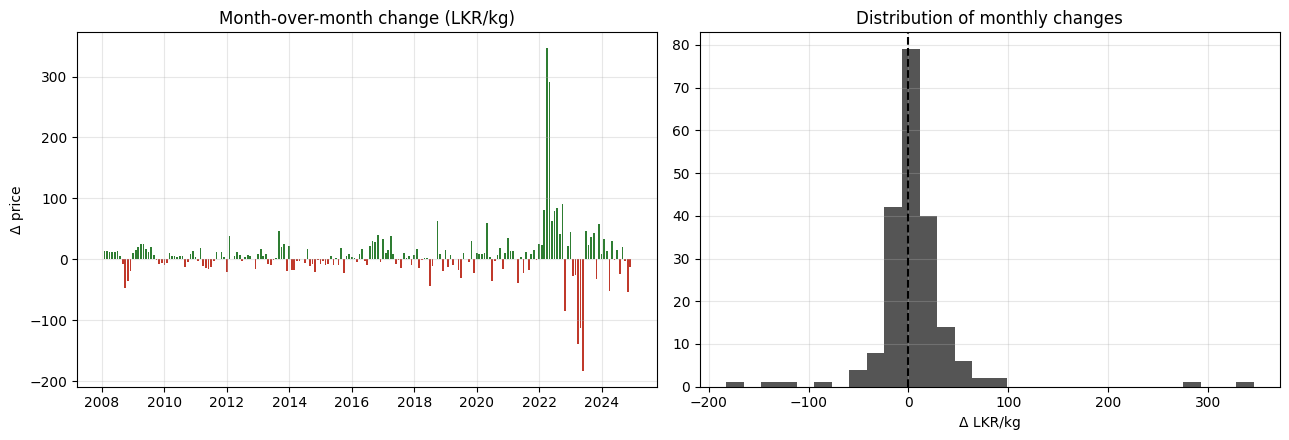

In [ ]:
# Month-over-month change (the thing ARIMA actually models after differencing)
chg = price.diff()
fig, ax = plt.subplots(1,2,figsize=(13,4.5))
ax[0].bar(chg.index, chg, width=20, color=np.where(chg>=0,'#2e7d32','#c0392b'))
ax[0].set_title('Month-over-month change (LKR/kg)'); ax[0].set_ylabel('Δ price')
ax[1].hist(chg.dropna(), bins=30, color='#555'); ax[1].axvline(0,color='k',ls='--')
ax[1].set_title('Distribution of monthly changes'); ax[1].set_xlabel('Δ LKR/kg')
plt.tight_layout(); plt.show()

## C. Is there seasonality? (visual check)

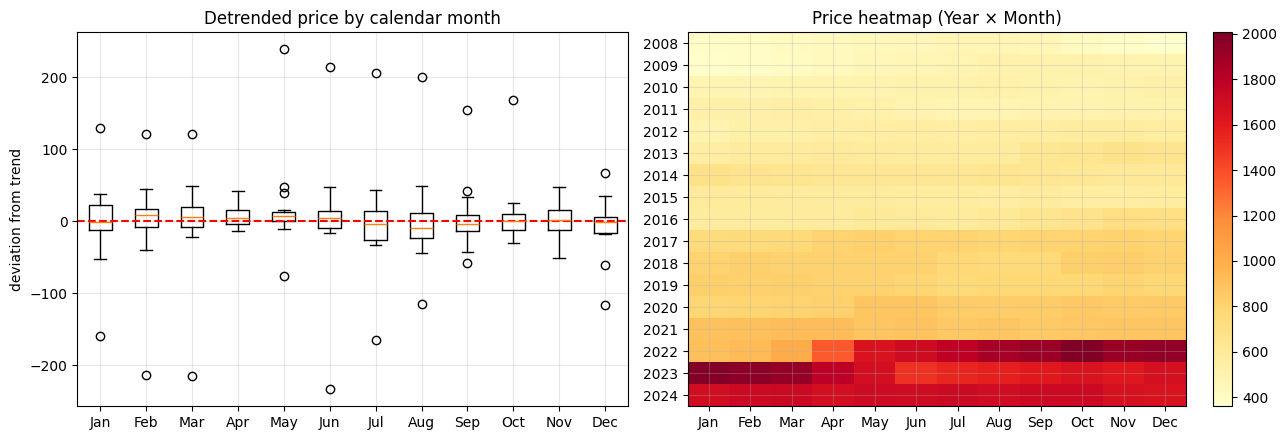

Boxplots sit around 0 with no repeating month pattern -> little/no seasonality (confirmed statistically in Part 2).


In [ ]:
# Monthly subseries: average price by calendar month (after removing the trend)
detrended = (price - price.rolling(12, center=True).mean()).dropna()
detrended_by_month = detrended.groupby(detrended.index.month)
order = range(1,13); labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, ax = plt.subplots(1,2,figsize=(13,4.5))
ax[0].boxplot([detrended_by_month.get_group(m).values for m in order], labels=labels)
ax[0].axhline(0,color='r',ls='--'); ax[0].set_title('Detrended price by calendar month'); ax[0].set_ylabel('deviation from trend')
# Year x Month heatmap
piv = price.copy(); pivt = pd.DataFrame({'y':piv.index.year,'m':piv.index.month,'v':piv.values}).pivot(index='y',columns='m',values='v')
im = ax[1].imshow(pivt, aspect='auto', cmap='YlOrRd')
ax[1].set_xticks(range(12)); ax[1].set_xticklabels(labels); ax[1].set_yticks(range(len(pivt))); ax[1].set_yticklabels(pivt.index)
ax[1].set_title('Price heatmap (Year × Month)'); plt.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

## D. Drivers & relationships

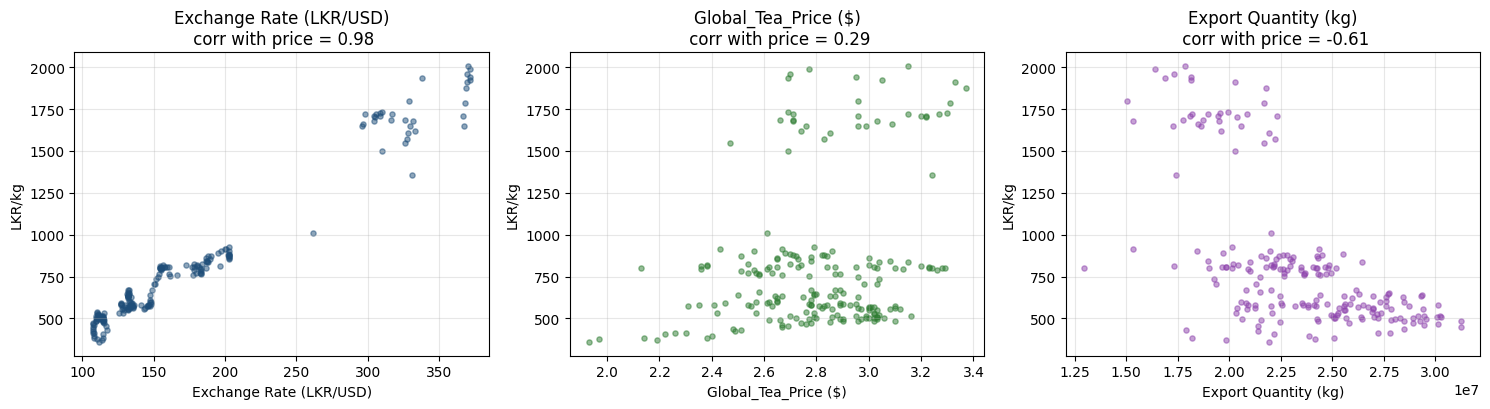

In [ ]:
drivers = {'Exchange Rate (LKR/USD)':'#1f4e79','Global_Tea_Price ($)':'#2e7d32','Export Quantity (kg)':'#8e44ad'}
fig, ax = plt.subplots(1,3,figsize=(15,4.2))
for i,(col,c) in enumerate(drivers.items()):
    ax[i].scatter(df[col], price, s=14, alpha=0.5, color=c)
    r = df[col].corr(price)
    ax[i].set_title(f'{col}\n corr with price = {r:.2f}'); ax[i].set_xlabel(col); ax[i].set_ylabel('LKR/kg')
plt.tight_layout(); plt.show()

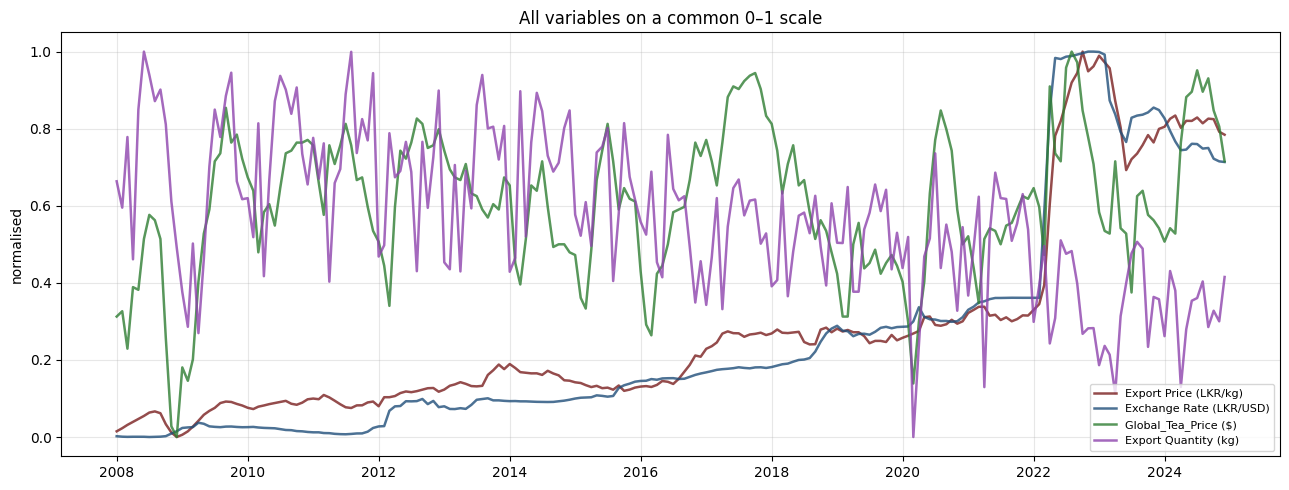

LKR price tracks the exchange rate closely; quantity moves independently.


In [ ]:
# Normalised overlay (0-1) so all series share one axis
norm = lambda s:(s-s.min())/(s.max()-s.min())
fig, ax = plt.subplots(figsize=(13,5))
for col,c in [('Export Price (LKR/kg)','#7a1f1f'),('Exchange Rate (LKR/USD)','#1f4e79'),
              ('Global_Tea_Price ($)','#2e7d32'),('Export Quantity (kg)','#8e44ad')]:
    ax.plot(df.index, norm(df[col]), label=col, lw=1.8, alpha=0.8, color=c)
ax.set_title('All variables on a common 0–1 scale'); ax.set_ylabel('normalised'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('LKR price tracks the exchange rate closely; quantity moves independently.')

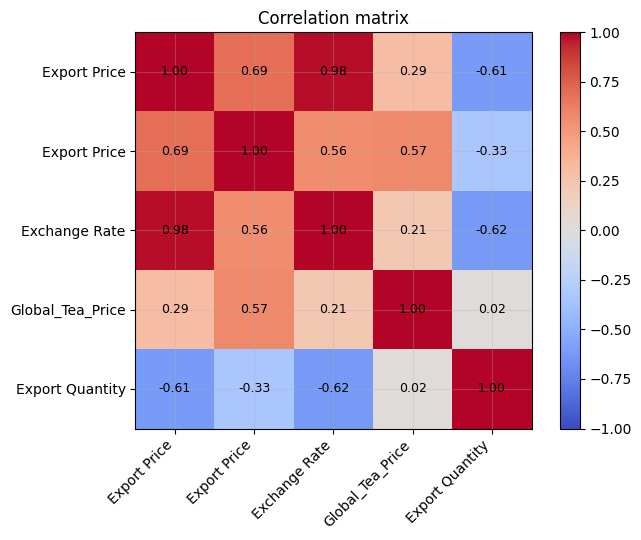

In [ ]:
# Correlation heatmap
cols=['Export Price (LKR/kg)','Export Price (USD/kg)','Exchange Rate (LKR/USD)','Global_Tea_Price ($)','Export Quantity (kg)']
corr=df[cols].corr()
fig,ax=plt.subplots(figsize=(7,5.5)); im=ax.imshow(corr,cmap='coolwarm',vmin=-1,vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels([c.split(' (')[0] for c in cols],rotation=45,ha='right')
ax.set_yticks(range(len(cols))); ax.set_yticklabels([c.split(' (')[0] for c in cols])
for i in range(len(cols)):
    for j in range(len(cols)): ax.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center',fontsize=9)
plt.colorbar(im,fraction=0.046); ax.set_title('Correlation matrix'); plt.tight_layout(); plt.show()